# Lab: Transfer Learning Implementation 


##### Estimated time needed:  30 minutes


Bu laboratuvarda, Keras'ta önceden eğitilmiş bir model kullanarak transfer öğrenmesini nasıl uygulayacağınızı öğreneceksiniz.

#### Öğrenim hedefleri

Bu laboratuvarın sonunda şunları yapabileceksiniz:

 - Gerekli kütüphaneleri içe aktaracak ve veri setini yükleyeceksiniz.
 - En üst katmanları hariç tutarak önceden eğitilmiş bir model olan VGG16'yı yükleyeceksiniz.
 - Temel modelin üzerine yeni katmanlar ekleyecek ve modeli derleyeceksiniz.
 - Modeli yeni veri kümesi üzerinde eğiteceksiniz.
 - Önceden eğitilmiş modelin bazı katmanlarının dondurmasını kaldıracak ve bunları ince ayarlayacaksınız.



Translated with DeepL.com (free version)

### Adım Adım Kılavuz: 

#### 1. Adım: Ortamı Hazırlama 

Başlamadan önce, gerekli kütüphaneleri içe aktardığınızdan emin olun: TensorFlow ve Keras. Keras, TensorFlow içinde `tensorflow.keras` olarak bulunur. 


In [1]:
!pip install tensorflow==2.16.2 matplotlib==3.9.1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 9.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB

Matplotlib is building the font cache; this may take a moment.
2026-03-26 13:49:09.192805: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 13:49:09.193988: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 13:49:09.198373: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 13:49:09.212208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-26 13:49:09.239338: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to regi

##### Açıklama:
- `tensorflow`, Python'da makine öğrenimi için kullanılan ana kütüphanedir.
- `Sequential`, katmanların doğrusal bir yığınından oluşan bir model oluşturmak için kullanılır.
- `Dense` ve `Flatten`, modelimizde kullanacağımız katman türleridir.

#### Step 2: Load Pre-trained Model 


In [2]:
# ImageNet üzerinde önceden eğitilmiş VGG16 modelini yükle
base_model = VGG16(weights=‘imagenet’, include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False  # Temel model katmanlarını sabitle



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Step 3: Create and Compile the Model 


In [3]:
model = Sequential([
    base_model,                      # Önceden eğitilmiş modeli ekler (özellik çıkarıcı)
    Flatten(),                       # 2D veriyi 1D hale getirir
    Dense(256, activation='relu'),  # 256 nöronlu gizli katman (özellik öğrenir)
    Dense(1, activation='sigmoid')  # Çıkış katmanı (binary sınıflandırma yapar)
])

model.compile(
    optimizer='adam',                # Ağırlıkları güncelleyen algoritma
    loss='binary_crossentropy',      # Hata hesaplama yöntemi (binary için)
    metrics=['accuracy']             # Model performansını ölçer
)

### **Create Placeholder Images**


In [4]:
import os
from PIL import Image
import numpy as np

os.makedirs('sample_data/class_a', exist_ok=True)  # class_a klasörünü oluşturur (varsa hata vermez)
os.makedirs('sample_data/class_b', exist_ok=True)  # class_b klasörünü oluşturur

for i in range(10):  # Her sınıf için 10 görsel üretir
    
    img = Image.fromarray(np.ones((224, 224, 3), dtype=np.uint8) * 255)  # Beyaz (255) görüntü oluşturur
    img.save(f'sample_data/class_a/img_{i}.jpg')  # class_a klasörüne kaydeder

    img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))  # Siyah (0) görüntü oluşturur
    img.save(f'sample_data/class_b/img_{i}.jpg')  # class_b klasörüne kaydeder

print("Sample images created in 'sample_data/'")  # İşlemin tamamlandığını yazdırır

Sample images created in 'sample_data/'


#### Step 4: Train the Model 


In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)  # Görselleri 0-255 → 0-1 aralığına normalize eder

train_generator = train_datagen.flow_from_directory(
    'sample_data',                 # Veri klasörünü belirtir
    target_size=(224, 224),        # Tüm görselleri 224x224 boyutuna getirir
    batch_size=32,                 # Veriyi 32’lik gruplar halinde modele verir
    class_mode='binary'            # İkili sınıflandırma yapılacağını belirtir
)

print(f"Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.")  # Kaç veri ve sınıf olduğunu gösterir

if train_generator.samples > 0:    # Eğer veri varsa
    model.fit(train_generator, epochs=10)  # Modeli 10 epoch boyunca eğitir

Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.6934
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 0.7506
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 3.1780
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.5000 - loss: 2.4123
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 0.4283
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 0.5164
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.5000 - loss: 0.9969
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 0.7459
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.2513
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.1023


#### Step 5: Fine-Tune the Model 


In [6]:
for layer in base_model.layers[-4:]:  # Temel modelin son 4 katmanını seçer
    layer.trainable = True             # Bu katmanların ağırlıklarını güncellenebilir hale getirir (ince ayar)

model.compile(
    optimizer='adam',                  # Ağırlıkları güncellemek için Adam optimizasyonu
    loss='binary_crossentropy',        # Hata hesaplama yöntemi (ikili sınıflandırma)
    metrics=['accuracy']               # Model performansını ölçmek için doğruluk
)

model.fit(train_generator, epochs=10)  # Modeli tekrar 10 epoch boyunca eğitir (ince ayarlı katmanlarla)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 0.2174
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 5.1836
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 1.2405
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.7395
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.7195
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.6635
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.6862
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.6557
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.6320
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.6012


### Exercises


#### Alıştırma 1: Eğitim ve Doğrulama Kaybını Grafiğe Aktarma

**Amaç:** Modelin öğrenme sürecini gözlemlemek için eğitim ve doğrulama kaybını grafiğe aktarın.

**Talimatlar:**
1. Eğitim kodunu, doğrulama verilerini de içerecek şekilde değiştirin.
2. Her bir epoch için eğitim ve doğrulama kaybını grafiğe aktarın.


Found 20 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.5229 - val_accuracy: 0.5000 - val_loss: 0.6152
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.6152 - val_accuracy: 0.5000 - val_loss: 0.9515
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.9515 - val_accuracy: 1.0000 - val_loss: 0.3367
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 1.0000 - loss: 0.3367 - val_accuracy: 0.5000 - val_loss: 0.5711
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.5711 - val_accuracy: 1.0000 - val_loss: 0.3143
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.3143 - val_accuracy: 1.0000 - val_loss: 0.3840
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 1.0000 - loss: 0.3840 - val_accuracy: 1.0000 - val_loss: 0.2754
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/st

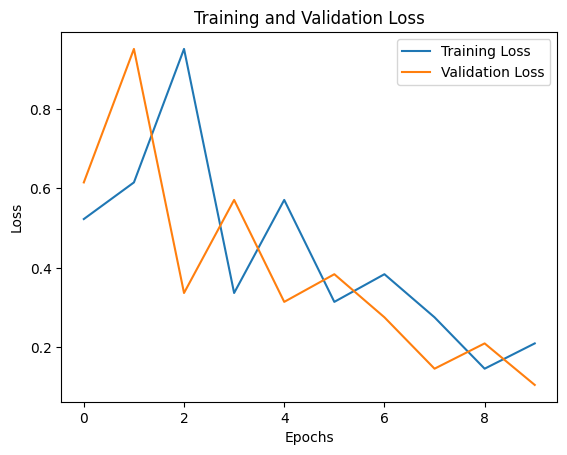

In [7]:
# Modify data generator to include validation data
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# Train the model with validation data
history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Hem training hem validation loss genel olarak aşağı yönlü trend izliyor

Epoch 9'da training loss ~0.21, validation loss ~0.09 seviyesine düşmüş — bu iyi bir öğrenme göstergesi

Validation loss'un training loss'tan daha düşük seyretmesi ilginç ama küçük veri setlerinde görülebilir

#### Alıştırma 2: Farklı Optimize Edicilerle Deney Yapın

**Amaç:** Farklı optimize edicilerle deney yapın ve bunların model performansı üzerindeki etkisini gözlemleyin.

**Talimatlar:**
1. Optimize ediciyi `adam`'dan `sgd` ve `rmsprop`'a değiştirin.
2. Modeli her bir optimize ediciyle yeniden eğitin ve doğruluk oranlarını karşılaştırın.


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.1051 - val_accuracy: 0.5000 - val_loss: 4.6616
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 4.6616 - val_accuracy: 0.5000 - val_loss: 1.1092
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 1.1092 - val_accuracy: 0.5000 - val_loss: 0.7173
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.7173 - val_accuracy: 0.5000 - val_loss: 0.6774
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.6774 - val_accuracy: 0.5000 - val_loss: 0.6602
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.6602 - val_accuracy: 0.5000 - val_loss: 0.6658
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.6658 - val_accuracy: 0.5000 - val_loss: 0.6400
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.6400 - val_accuracy: 0.5000 - val_loss: 0.6083


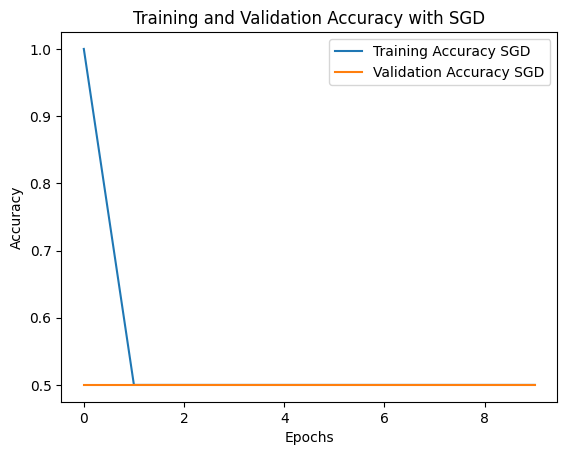

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 0.1051 - val_accuracy: 0.5000 - val_loss: 11.6441
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 11.6441 - val_accuracy: 0.5000 - val_loss: 1.0352
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 1.0352 - val_accuracy: 0.5000 - val_loss: 0.7209
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.7209 - val_accuracy: 0.5000 - val_loss: 0.8991
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.8991 - val_accuracy: 0.5000 - val_loss: 1.3039
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 1.3039 - val_accuracy: 0.5000 - val_loss: 0.7031
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.7031 - val_accuracy: 1.0000 - val_loss: 0.5087
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 1.0000 - loss: 0.5087 - val_accuracy: 0.5000 - val_loss: 2.077

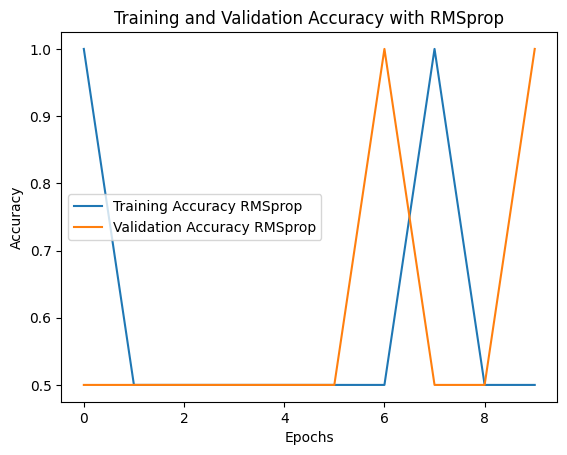

In [8]:
from tensorflow.keras.models import clone_model
import matplotlib.pyplot as plt

def reset_model(model):
    # Modeli klonlayarak ağırlıkları sıfırlamaya hazırlar
    model_clone = clone_model(model)          # Model yapısını kopyalar
    model_clone.set_weights(model.get_weights())  # Ağırlıkları orijinal modelden alır
    return model_clone

initial_model = reset_model(model)  # Başlangıç modeli için ağırlıkları hazırlar

# --- SGD Deneyi ---
sgd_model = reset_model(initial_model)  # Modeli sıfırlar
sgd_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])  # SGD ile derler
history_sgd = sgd_model.fit(train_generator, epochs=10, validation_data=validation_generator)  # Eğitir

# SGD doğruluk grafiği
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy SGD')       # Eğitim doğruluğu
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy SGD') # Doğrulama doğruluğu
plt.title('Training and Validation Accuracy with SGD')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- RMSprop Deneyi ---
rmsprop_model = reset_model(initial_model)  # Modeli sıfırlar
rmsprop_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])  # RMSprop ile derler
history_rmsprop = rmsprop_model.fit(train_generator, epochs=10, validation_data=validation_generator)  # Eğitir

# RMSprop doğruluk grafiği
plt.plot(history_rmsprop.history['accuracy'], label='Training Accuracy RMSprop')       # Eğitim doğruluğu
plt.plot(history_rmsprop.history['val_accuracy'], label='Validation Accuracy RMSprop') # Doğrulama doğruluğu
plt.title('Training and Validation Accuracy with RMSprop')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Accuracy değerleri 0.5 ile 1.0 arasında vahşice sallanıyor — bu rastgele tahmin (coin flip) ile gerçek öğrenme arasında gidip geliyor demek

Epoch 0'da 1.0'a çıkıp anında 0.5'e düşüyor, sonra tekrar zıplıyor

Bu tür periyodik spike'lar genellikle öğrenme oranının çok yüksek olduğunu gösterir

Genel değerlendirme: RMSprop bu konfigürasyonda kararsız ve güvenilmez. Model hiçbir şey öğrenemiyor, sürekli salınım yapıyor. ❌


#### Alıştırma 3: Modeli Test Kümesinde Değerlendirme

**Amaç:** Genelleştirme performansını değerlendirmek üzere, ince ayar yapılmış modeli daha önce görülmemiş bir test kümesinde değerlendirin.

**Talimatlar:**
1. Ayrı bir test kümesi yükleyin.
2. Modeli bu test kümesinde değerlendirin ve doğruluk oranını ve kayıp değerini bildirin.


In [9]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Evaluate the fine-tuned model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Found 24 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.1051
Test Accuracy: 100.00%
Test Loss: 0.1051
